# EDA: еженедельный детализированный отчёт Wildberries

**Цель:** разобрать продажи, выручку, категории и географию доставок по отчёту продавца WB, выделить ключевые метрики и паттерны для решений по ассортименту и логистике.

**Данные:** еженедельный детализированный отчёт — поставки, предмет/категория, даты заказа и продажи, количество, цены, комиссии WB, сумма к перечислению продавцу, офис доставки и др.

## Импорт библиотек и загрузка данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Blues")
pd.set_option("display.max_columns", 30)

# Читаемость графиков: шрифты и размеры
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

# Файл отчёта — объединённый отчёт из 5 недельных отчётов
FILE_PATH = "отчет_объединенный.csv"
df = pd.read_csv(FILE_PATH, encoding="utf-8-sig", low_memory=False)

df.head(3)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240187 entries, 0 to 240186
Data columns (total 63 columns):
 #   Column                                                             Non-Null Count   Dtype  
---  ------                                                             --------------   -----  
 0   №                                                                  240187 non-null  int64  
 1   Номер поставки                                                     240187 non-null  int64  
 2   Предмет                                                            37981 non-null   object 
 3   Код номенклатуры                                                   240187 non-null  int64  
 4   Бренд                                                              37291 non-null   object 
 5   Артикул поставщика                                                 37981 non-null   object 
 6   Название                                                           37981 non-null   object 
 7   Размер     

## Первичный обзор, очистка и подготовка

In [2]:
# Приведение имён колонок: пробелы и спецсимволы → подчёркивание, нижний регистр
def clean_col(c):
    s = str(c).strip().lower().replace(" ", "_").replace("%", "pct").replace(",", "")
    return "".join("_" if not (x.isalnum() or x == "_") else x for x in s)

df.columns = [clean_col(c) for c in df.columns]
# Ключевые колонки (названия после очистки могут отличаться — смотрим факт)
cols = list(df.columns)
date_order = [c for c in cols if "дата_заказа" in c or "date" in c and "order" in c.lower()]
date_sale = [c for c in cols if "дата_продажи" in c or "sale" in c.lower()]
qty = [c for c in cols if c == "кол-во" or "quantity" in c.lower()]
print([c for c in cols[:25]])

['_', 'номер_поставки', 'предмет', 'код_номенклатуры', 'бренд', 'артикул_поставщика', 'название', 'размер', 'баркод', 'тип_документа', 'обоснование_для_оплаты', 'дата_заказа_покупателем', 'дата_продажи', 'кол_во', 'цена_розничная', 'вайлдберриз_реализовал_товар__пр_', 'согласованный_продуктовый_дисконт_pct', 'промокод_pct', 'итоговая_согласованная_скидка_pct', 'цена_розничная_с_учетом_согласованной_скидки', 'размер_снижения_квв_из_за_рейтинга_pct', 'размер_изменения_квв_из_за_акции_pct', 'скидка_постоянного_покупателя__спп__pct', 'размер_квв_pct', 'размер__квв_без_ндс_pct_базовый']


In [3]:
# Маппинг ключевых колонок по подстрокам (устойчиво к разному выводу clean_col)
def find_col(key_substrings):
    if isinstance(key_substrings, str):
        key_substrings = [key_substrings]
    for c in df.columns:
        if all(k in c for k in key_substrings):
            return c
    return None
col_hints = {
    "order_date": ["дата_заказа", "покупателем"],
    "sale_date": ["дата_продажи"],
    "quantity": ["кол_во"],
    "size": ["размер"],
    "price_retail": ["цена_розничная"],
    "wb_revenue": ["вайлдберриз_реализовал"],
    "payout": ["перечислению_продавцу"],
    "category": ["предмет"],
    "product_name": ["название"],
    "delivery_office": ["офиса_доставки"],
    "nomenclature_code": ["код_номенклатуры"],
    "warehouse": ["склад"],
}
rename_map = {}
for std_name, hints in col_hints.items():
    found = find_col(hints)
    if found and found not in rename_map.values():
        rename_map[found] = std_name
df = df.rename(columns=rename_map)
print("Переименованы:", list(rename_map.values()))

Переименованы: ['order_date', 'sale_date', 'quantity', 'size', 'price_retail', 'wb_revenue', 'payout', 'category', 'product_name', 'nomenclature_code', 'warehouse']


In [4]:
# Преобразование дат
for col in ["order_date", "sale_date"]:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

# Числа: в отчёте часть полей с запятой как десятичный разделитель
def to_num(ser):
    if ser.dtype == object:
        return pd.to_numeric(ser.astype(str).str.replace(",", "."), errors="coerce")
    return pd.to_numeric(ser, errors="coerce")

for col in ["quantity", "price_retail", "wb_revenue", "payout"]:
    if col in df.columns:
        df[col] = to_num(df[col])

# Дубликаты и пропуски
df = df.drop_duplicates()
critical = [c for c in ["sale_date", "payout", "category"] if c in df.columns]
df = df.dropna(subset=critical)
print(f"Строк после очистки: {len(df)}")
print(df[[c for c in ["order_date", "sale_date", "quantity", "price_retail", "payout", "category"] if c in df.columns]].dtypes)

Строк после очистки: 37981
order_date      datetime64[ns]
sale_date       datetime64[ns]
quantity                 int64
price_retail           float64
payout                 float64
category                object
dtype: object


**Вывод:** Имена колонок приведены к единому виду, ключевые поля переименованы для удобства. Даты и числовые поля преобразованы; строки с пропусками в критических полях удалены. Данные готовы к расчёту метрик.

## Базовые метрики: поставки, период, выручка, перечисление

In [5]:
ship_col = [c for c in df.columns if "номер_поставки" in c or "поставк" in c][:1]
ship_col = ship_col[0] if ship_col else df.columns[1]

n_shipments = df[ship_col].nunique()
date_min = df["sale_date"].min()
date_max = df["sale_date"].max()
total_qty = df["quantity"].sum() if "quantity" in df.columns else 0
total_wb = df["wb_revenue"].sum() if "wb_revenue" in df.columns else 0
total_payout = df["payout"].sum() if "payout" in df.columns else 0

print(f"Уникальных поставок:  {n_shipments:,}")
print(f"Период продаж:        {date_min.date()} — {date_max.date()}")
print(f"Суммарное кол-во:    {total_qty:,.0f}")
print(f"Выручка WB (реализ.): {total_wb:,.2f}")
print(f"К перечислению:      {total_payout:,.2f}")

Уникальных поставок:  74
Период продаж:        2024-11-09 — 2025-08-31
Суммарное кол-во:    37,239
Выручка WB (реализ.): 24,600,121.86
К перечислению:      18,429,804.50


**Вывод:** По отчёту виден объём поставок и период. Сумма «к перечислению» — фактическая выручка продавца после комиссий и скидок; выручка WB — объём реализации до вычетов.

## Воронка выручки и вычетов

Верификация фактических выплат:
  Сумма по колонке «К перечислению Продавцу за реализованный Товар»: 18,429,804.50 руб.
  Итог воронки (последняя ступень): 18,429,804.50 руб.
  Совпадение: расхождение < 0.01 руб. Результат верифицирован.


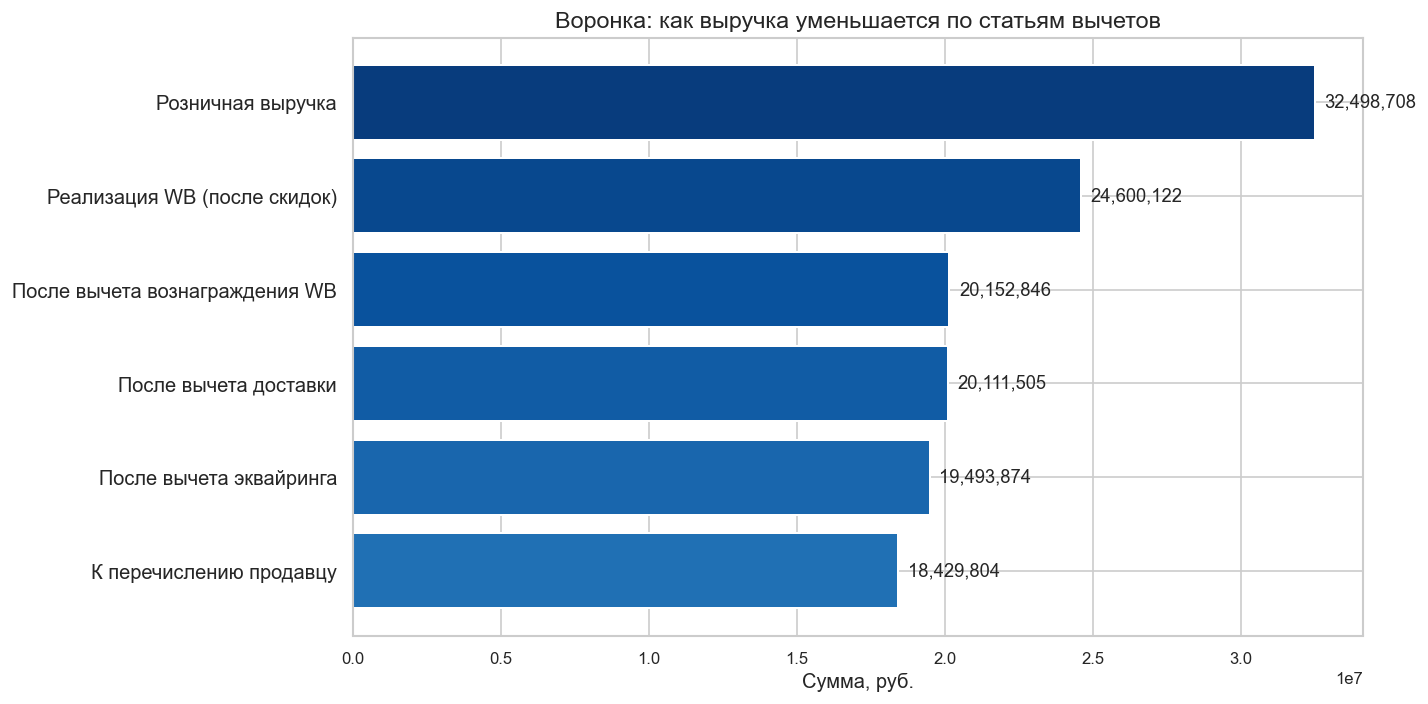

In [6]:
def find_col_funnel(dataf, key_substrings):
    if isinstance(key_substrings, str):
        key_substrings = [key_substrings]
    for c in dataf.columns:
        if all(k in c.lower() for k in key_substrings):
            return c
    return None

def to_num_funnel(ser):
    if ser.dtype == object:
        return pd.to_numeric(ser.astype(str).str.replace(",", "."), errors="coerce")
    return pd.to_numeric(ser, errors="coerce")

stages = []
labels = []

if "price_retail" in df.columns:
    qty = df["quantity"] if "quantity" in df.columns else 1
    retail = (df["price_retail"] * qty).sum()
    stages.append(retail)
    labels.append("Розничная выручка")

if "wb_revenue" in df.columns:
    wb_rev = df["wb_revenue"].sum()
    stages.append(wb_rev)
    labels.append("Реализация WB (после скидок)")

wb_comm_col = find_col_funnel(df, ["вознаграждение", "вв"]) or find_col_funnel(df, ["вознаграждение_вайлдберриз"])
delivery_col = find_col_funnel(df, ["услуги", "доставк"]) or find_col_funnel(df, ["доставке_товара"])
acquiring_col = find_col_funnel(df, ["эквайринг"]) or find_col_funnel(df, ["комиссии_за_организацию_платежей"])

wb_comm = df[wb_comm_col].pipe(to_num_funnel).sum() if wb_comm_col is not None else 0
delivery = df[delivery_col].pipe(to_num_funnel).sum() if delivery_col is not None else 0
acquiring = df[acquiring_col].pipe(to_num_funnel).sum() if acquiring_col is not None else 0

if "wb_revenue" in df.columns and (wb_comm > 0 or delivery > 0 or acquiring > 0):
    wb_rev = df["wb_revenue"].sum()
    after_comm = wb_rev - wb_comm
    if wb_comm > 0:
        stages.append(after_comm)
        labels.append("После вычета вознаграждения WB")
    after_del = after_comm - delivery
    if delivery > 0:
        stages.append(after_del)
        labels.append("После вычета доставки")
    after_acq = after_del - acquiring
    if acquiring > 0:
        stages.append(after_acq)
        labels.append("После вычета эквайринга")

if "payout" in df.columns:
    payout_sum = df["payout"].sum()
    stages.append(payout_sum)
    labels.append("К перечислению продавцу")

actual_col = None
if "payout" in df.columns:
    actual_col = "payout"
else:
    actual_col = find_col_funnel(df, ["перечисл", "продавцу"]) or find_col_funnel(df, ["к_перечислению"]) or find_col_funnel(df, ["выплат"])
if actual_col is not None and len(stages) >= 1:
    sum_actual = df[actual_col].pipe(to_num_funnel).sum() if actual_col != "payout" else df["payout"].sum()
    result_funnel = stages[-1]
    diff = abs(sum_actual - result_funnel)
    col_desc = "К перечислению Продавцу за реализованный Товар" if actual_col == "payout" else actual_col
    print("Верификация фактических выплат:")
    print(f"  Сумма по колонке «{col_desc}»: {sum_actual:,.2f} руб.")
    print(f"  Итог воронки (последняя ступень): {result_funnel:,.2f} руб.")
    if diff < 0.01:
        print("  Совпадение: расхождение < 0.01 руб. Результат верифицирован.")
    else:
        print(f"  Расхождение: {diff:,.2f} руб.")

if len(stages) >= 2:
    fig, ax = plt.subplots(figsize=(12, max(5, len(stages) * 1.0)))
    y_pos = list(range(len(stages)))
    colors = [plt.cm.Blues(0.95 - 0.2 * i / max(len(stages) - 1, 1)) for i in range(len(stages))]
    ax.barh(y_pos, stages, color=colors, edgecolor="white", linewidth=1.2)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=12)
    ax.set_xlabel("Сумма, руб.", fontsize=12)
    ax.set_title("Воронка: как выручка уменьшается по статьям вычетов", fontsize=14)
    for i, v in enumerate(stages):
        ax.text(v + max(stages) * 0.01, i, f"{v:,.0f}", va="center", fontsize=11)
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("Недостаточно данных для воронки (нужны price_retail, wb_revenue, payout).")

## Средний чек

In [7]:
code_col = "nomenclature_code" if "nomenclature_code" in df.columns else None
if code_col and "payout" in df.columns:
    by_code = df.groupby(code_col).agg(
        sum_payout=("payout", "sum"),
        cnt=("payout", "count"),
    ).assign(avg_check=lambda x: (x["sum_payout"] / x["cnt"]).round(2))
    by_code = by_code.sort_values("sum_payout", ascending=False)
    by_code = by_code.rename(columns={"sum_payout": "Сумма к перечислению", "cnt": "Позиций", "avg_check": "Средний чек, руб."})
    print("Средний чек (агрегация по коду номенклатуры):")
    display(by_code)
else:
    print("Нет полей код_номенклатуры или payout.")

Средний чек (агрегация по коду номенклатуры):


,Сумма к перечислению,Позиций,"Средний чек, руб."
nomenclature_code,,,
227786926,4429004.81,8195,540.45
116767385,3007815.62,7315,411.18
392373557,2822901.02,5092,554.38
428337309,1366391.40,1893,721.81
292379879,1006634.53,1156,870.79
227794914,926139.15,1931,479.62
227790774,705132.83,1938,363.85
227787774,618681.83,1621,381.67
227788256,515047.00,1267,406.51


## География: склады

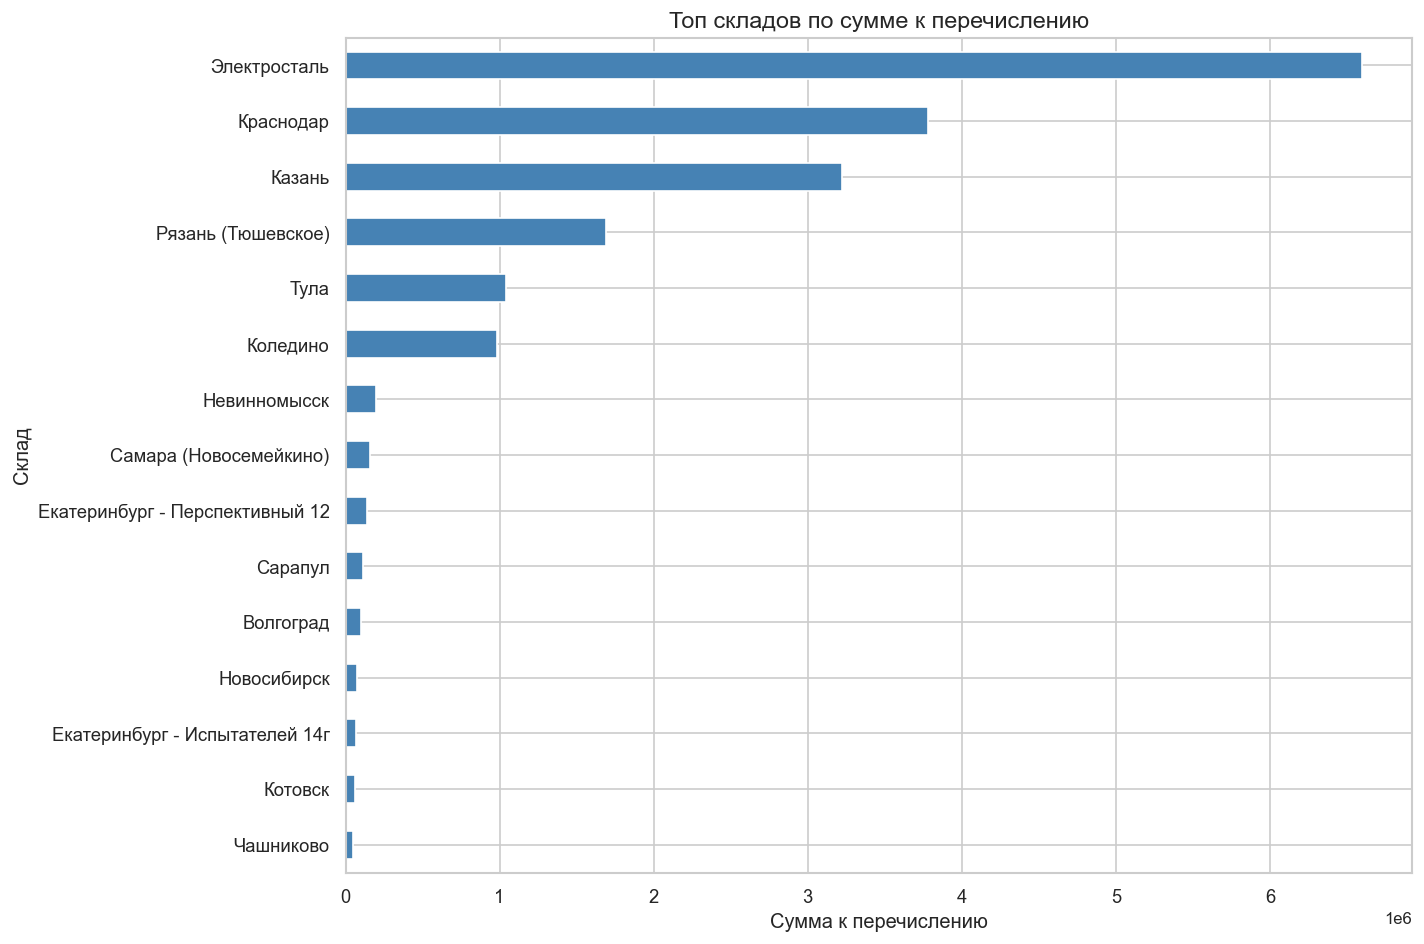

In [8]:
wh_col = "warehouse" if "warehouse" in df.columns else None
if wh_col and "payout" in df.columns:
    by_wh = df.groupby(wh_col, dropna=False).agg(
        payout=("payout", "sum"),
        rows=("payout", "count"),
    ).reset_index().rename(columns={"payout": "sum_payout"})
    top = by_wh.nlargest(15, "sum_payout").dropna(subset=[wh_col])
    if len(top) > 0:
        fig, ax = plt.subplots(figsize=(12, 8))
        top.sort_values("sum_payout").plot(x=wh_col, y="sum_payout", kind="barh", ax=ax, color="steelblue", legend=False)
        ax.set_title("Топ складов по сумме к перечислению", fontsize=14)
        ax.set_ylabel("Склад", fontsize=12)
        ax.set_xlabel("Сумма к перечислению", fontsize=12)
        ax.tick_params(axis="both", labelsize=11)
        plt.tight_layout()
        plt.show()
    else:
        print("Нет данных по складам для построения графика.")
else:
    print("Нет поля Склад или payout.")

**Вывод:** Топ складов показывает, с каких складов идёт основной объём и куда ориентировать логистику.

## Топ-3 позиций по продажам для каждого склада

In [9]:
wh_col = "warehouse" if "warehouse" in df.columns else None
code_col = "nomenclature_code" if "nomenclature_code" in df.columns else None
name_col = "product_name" if "product_name" in df.columns else None
if wh_col and code_col and "payout" in df.columns:
    by_wh_code = df.groupby([wh_col, code_col]).agg(
        sum_payout=("payout", "sum"),
        cnt=("payout", "count"),
    ).reset_index()
    top3_per_wh = (
        by_wh_code.groupby(wh_col, group_keys=False)
        .apply(lambda g: g.nlargest(3, "sum_payout"))
        .reset_index(drop=True)
    )
    if name_col and name_col in df.columns:
        names = df.drop_duplicates([code_col, name_col])[[code_col, name_col]].set_index(code_col)[name_col]
        top3_per_wh["product_name"] = top3_per_wh[code_col].map(names)
    top3_per_wh = top3_per_wh.rename(columns={"sum_payout": "Сумма к перечислению", "cnt": "Позиций"})
    print("Топ-3 позиций (по сумме к перечислению) для каждого склада:")
    display(top3_per_wh)
else:
    print("Нет полей Склад, код номенклатуры или payout.")

Топ-3 позиций (по сумме к перечислению) для каждого склада:


C:\Users\Виталий\AppData\Local\Temp\ipykernel_33900\1470750906.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.nlargest(3, "sum_payout"))


,warehouse,nomenclature_code,Сумма к перечислению,Позиций,product_name
0,Актобе,323187204,417.99,1,Набор женских топов летних цветные
1,Актобе,116767385,417.16,1,Женский топ кроп спортивный вечерний базовый н...
2,Астана Карагандинское шоссе,116767385,3342.76,8,Женский топ кроп спортивный вечерний базовый н...
3,Астана Карагандинское шоссе,392373557,2828.96,5,Женский топ кроп спортивный вечерний базовый н...
4,Астана Карагандинское шоссе,227786926,2741.00,5,Женский топ кроп спортивный вечерний топ лифчик
...,...,...,...,...,...
165,Электросталь,227786926,1001348.30,1843,Женский топ кроп спортивный вечерний топ лифчик
166,Электросталь,428337309,743426.98,1024,Женский топ кроп спортивный вечерний топ лифчик
167,Южный федеральный округ МП,110119776,0.00,1,Корсет вечерний пояс утягивающий бандаж послео...
168,Южный федеральный округ МП,227786926,0.00,2,Женский топ кроп спортивный вечерний топ лифчик


## Динамика продаж по датам

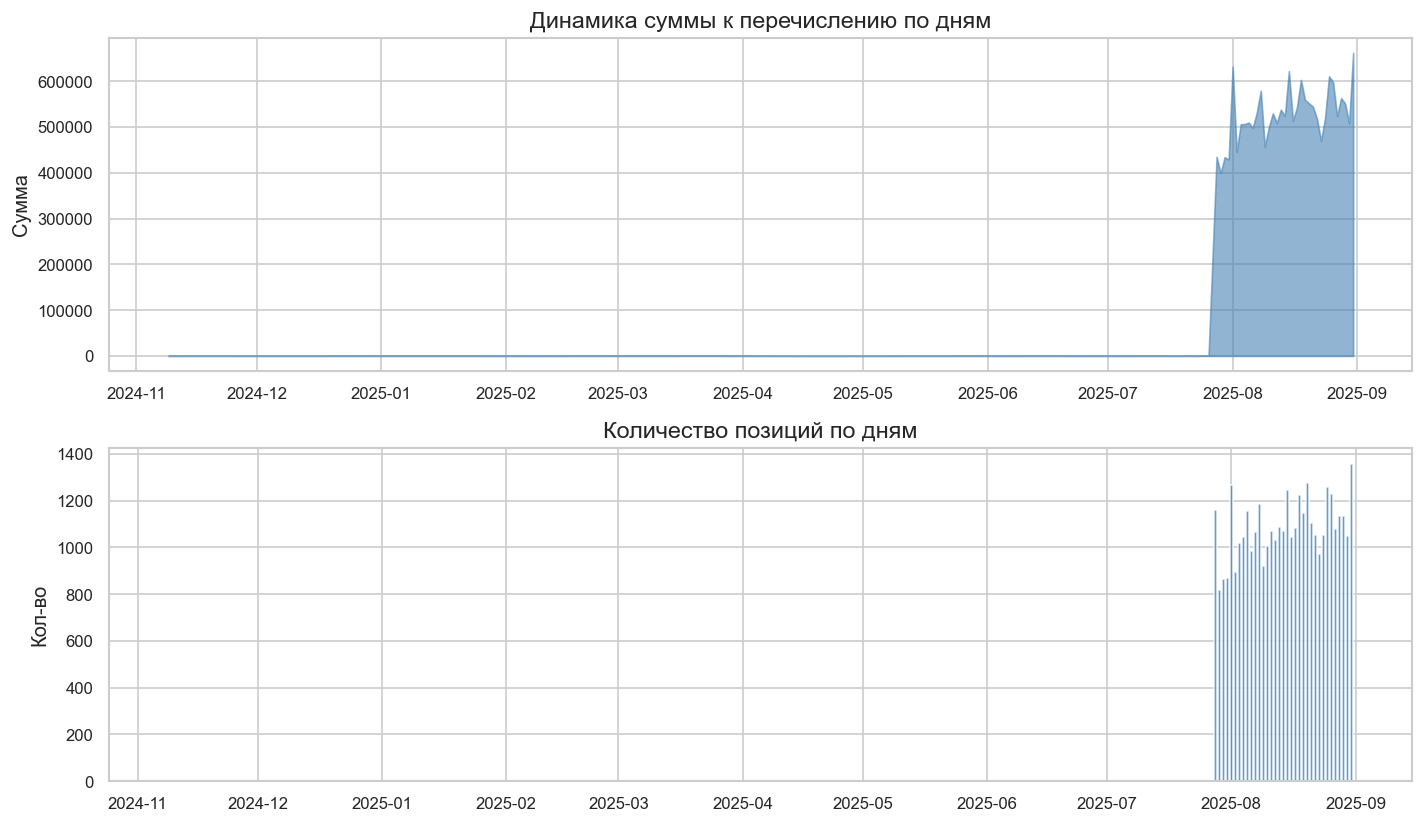

In [10]:
daily = df.groupby("sale_date").agg(
    payout=("payout", "sum") if "payout" in df.columns else (df.columns[0], "count"),
    rows=(df.columns[0], "count"),
).reset_index()
if len(daily) == 0:
    print("Нет данных по датам для графика.")
else:
    if "payout" in df.columns:
        fig, axes = plt.subplots(2, 1, figsize=(12, 7))
        axes[0].fill_between(daily["sale_date"], daily["payout"], alpha=0.6, color="steelblue")
        axes[0].set_title("Динамика суммы к перечислению по дням")
        axes[0].set_ylabel("Сумма")
        axes[1].bar(daily["sale_date"], daily["rows"], color="steelblue", alpha=0.8)
        axes[1].set_title("Количество позиций по дням")
        axes[1].set_ylabel("Кол-во")
    else:
        plt.figure(figsize=(12, 4))
        plt.bar(daily["sale_date"], daily["rows"], color="steelblue")
        plt.title("Количество позиций по дням")
    plt.tight_layout()
    plt.show()

**Вывод:** По графикам видна ежедневная динамика выручки и количества позиций в отчётном периоде.

## Категории (предмет) и ассортимент

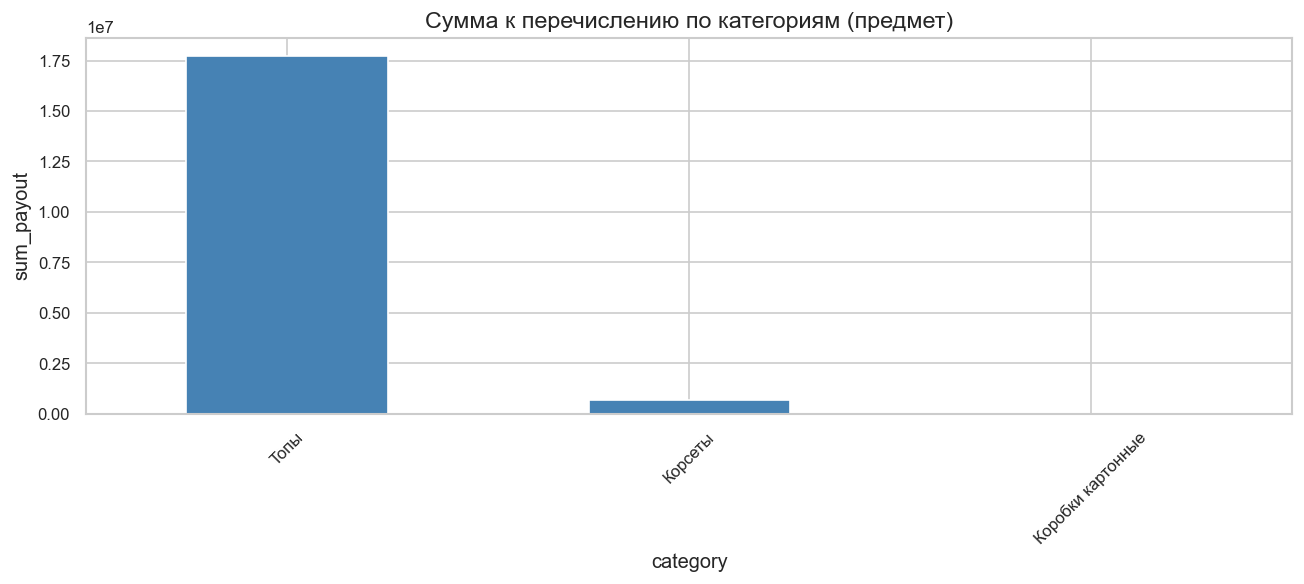

In [11]:
if "category" in df.columns:
    by_cat = df.groupby("category").agg(
        payout=("payout", "sum") if "payout" in df.columns else (df.columns[0], "count"),
        rows=("payout", "count") if "payout" in df.columns else (df.columns[0], "count"),
    ).reset_index()
    if "payout" in df.columns:
        by_cat = by_cat.rename(columns={"payout": "sum_payout"})
        by_cat = by_cat.sort_values("sum_payout", ascending=False)
        col = "sum_payout"
    else:
        by_cat = by_cat.sort_values("rows", ascending=False)
        col = "rows"
    if len(by_cat) > 0:
        fig, ax = plt.subplots(figsize=(11, 5))
        by_cat.plot(x="category", y=col, kind="bar", ax=ax, color="steelblue", legend=False)
        ax.set_title("Сумма к перечислению по категориям (предмет)")
        ax.set_ylabel(col)
        ax.tick_params(axis="x", rotation=45)
        plt.tight_layout()
        plt.show()
    else:
        print("Нет данных по категориям.")

**Вывод:** Распределение по предметам показывает, какие категории дают основной вклад в выручку продавца.

## Товарные группы: расширенная аналитика

## Размеры: распределение и выручка

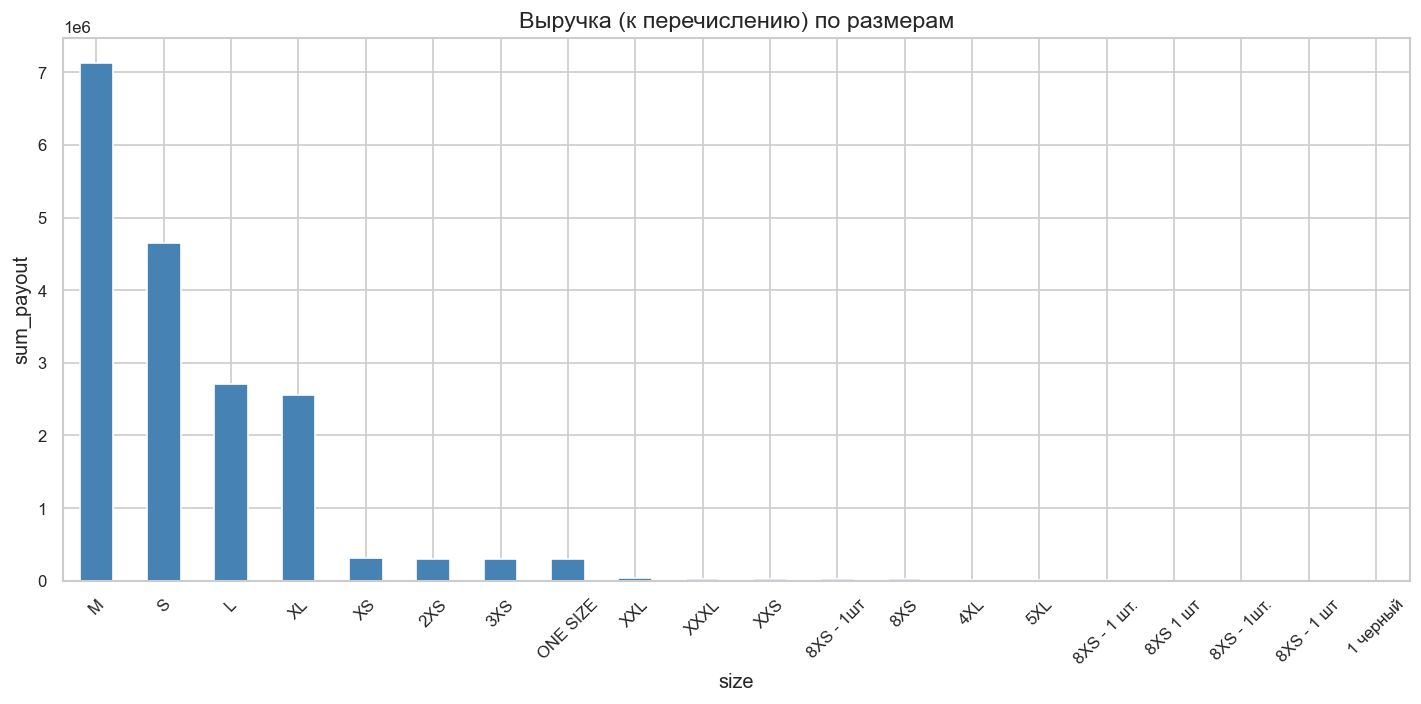

In [12]:
size_col = "size" if "size" in df.columns else None
if size_col and df[size_col].notna().any():
    by_size = df.groupby(size_col, dropna=False).agg(
        sum_payout=("payout", "sum") if "payout" in df.columns else (df.columns[0], "count"),
        cnt=("payout", "count") if "payout" in df.columns else (df.columns[0], "count"),
    ).reset_index()
    by_size = by_size[by_size[size_col].notna() & (by_size[size_col].astype(str).str.strip() != "")]
    if "payout" in df.columns:
        by_size = by_size.sort_values("sum_payout", ascending=False).head(20)
        col = "sum_payout"
    else:
        by_size = by_size.sort_values("cnt", ascending=False).head(20)
        col = "cnt"
    if len(by_size) > 0:
        fig, ax = plt.subplots(figsize=(12, 6))
        by_size.plot(x=size_col, y=col, kind="bar", ax=ax, color="steelblue", legend=False)
        ax.set_title("Выручка (к перечислению) по размерам")
        ax.set_ylabel(col)
        ax.tick_params(axis="x", rotation=45)
        plt.tight_layout()
        plt.show()
    else:
        print("Нет данных по размерам.")
else:
    print("Колонка размера отсутствует или пуста.")

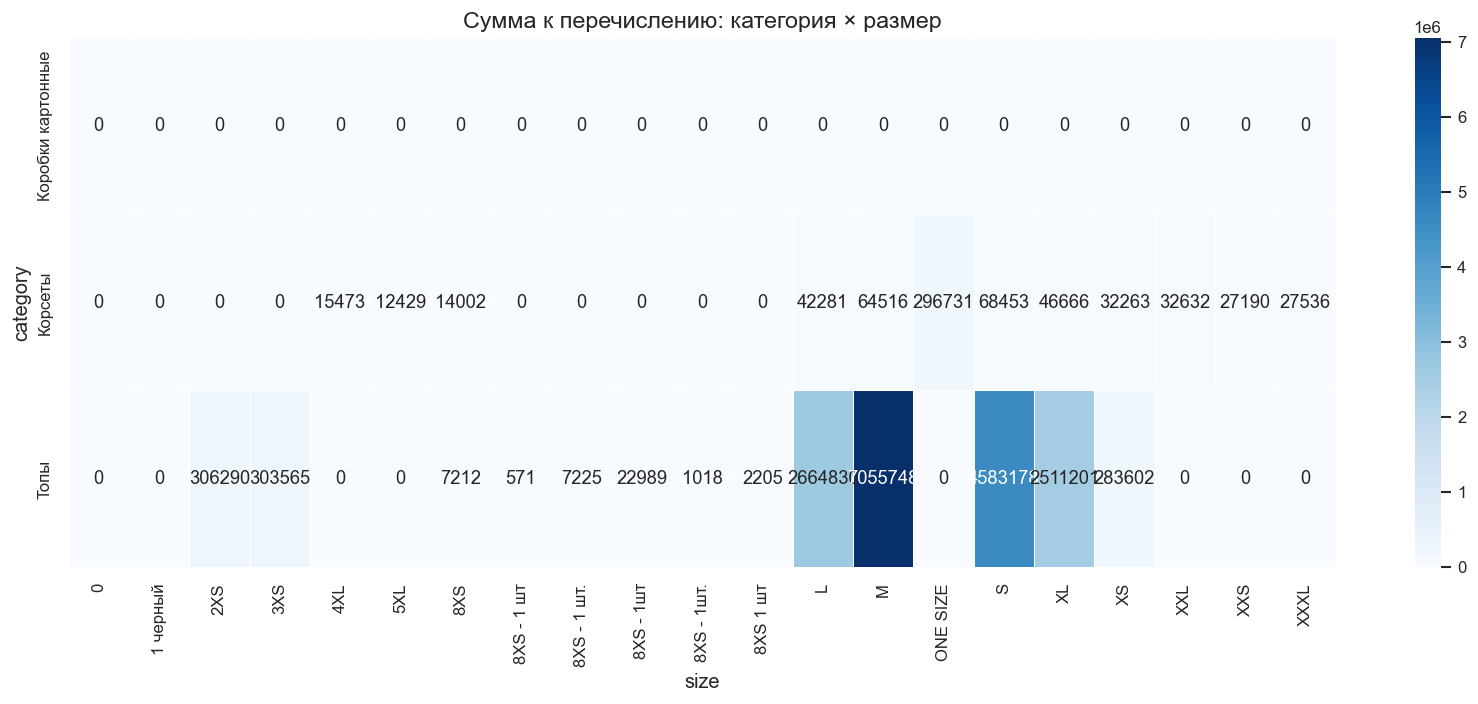

In [13]:
if size_col and "category" in df.columns and "payout" in df.columns:
    cross = pd.crosstab(df["category"], df[size_col].fillna("-"), values=df["payout"], aggfunc="sum")
    cross = cross.fillna(0)
    if cross.size > 0:
        fig, ax = plt.subplots(figsize=(14, 6))
        sns.heatmap(cross, ax=ax, cmap="Blues", fmt=".0f", annot=True, linewidths=0.5)
        ax.set_title("Сумма к перечислению: категория × размер")
        plt.tight_layout()
        plt.show()

## Маржинальность по товарной группе

In [14]:
if "category" in df.columns and "payout" in df.columns and "price_retail" in df.columns:
    df_m = df[df["price_retail"] > 0].copy()
    df_m["payout_share"] = (df_m["payout"] / df_m["price_retail"] * 100).round(1)
    by_cat_m = df_m.groupby("category").agg(
        sum_payout=("payout", "sum"),
        sum_retail=("price_retail", "sum"),
        mean_share=("payout_share", "mean"),
        cnt=("payout", "count"),
    ).round(2)
    by_cat_m["margin_pct"] = (by_cat_m["sum_payout"] / by_cat_m["sum_retail"] * 100).round(1)
    by_cat_m = by_cat_m.sort_values("margin_pct", ascending=False)
    by_cat_m.columns = ["Сумма к перечислению", "Сумма розница", "Средняя доля payout, %", "Кол-во", "Маржа (доля от розницы), %"]
    display(by_cat_m)
else:
    print("Нет полей category, payout или price_retail.")

,Сумма к перечислению,Сумма розница,"Средняя доля payout, %",Кол-во,"Маржа (доля от розницы), %"
category,,,,,
Топы,17732411.42,31300189.15,56.61,34743,56.7
Корсеты,678804.96,1198518.41,56.63,2133,56.6


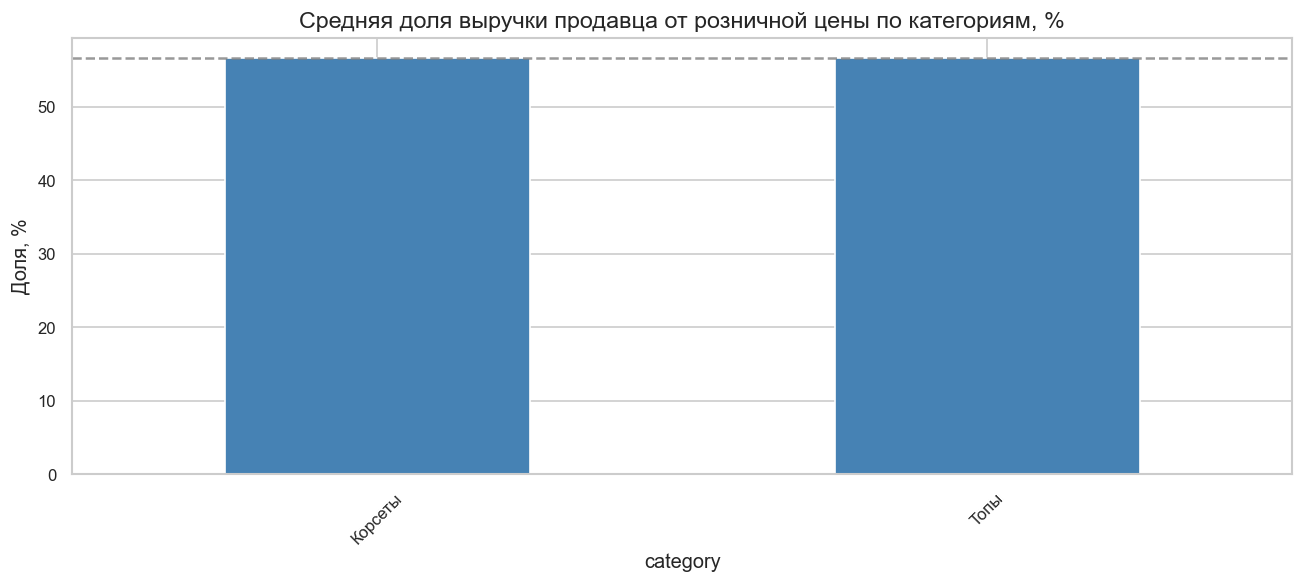

In [15]:
if "category" in df.columns and "payout" in df.columns and "price_retail" in df.columns:
    df_m = df[df["price_retail"] > 0].copy()
    df_m["margin_pct"] = (df_m["payout"] / df_m["price_retail"] * 100)
    by_cat_m = df_m.groupby("category")["margin_pct"].mean().round(1).sort_values(ascending=False)
    if len(by_cat_m) > 0:
        fig, ax = plt.subplots(figsize=(11, 5))
        by_cat_m.plot(kind="bar", ax=ax, color="steelblue", legend=False)
        ax.set_title("Средняя доля выручки продавца от розничной цены по категориям, %")
        ax.set_ylabel("Доля, %")
        ax.axhline(by_cat_m.mean(), color="gray", linestyle="--", alpha=0.8)
        ax.tick_params(axis="x", rotation=45)
        plt.tight_layout()
        plt.show()

## Топ товаров по выручке и количеству

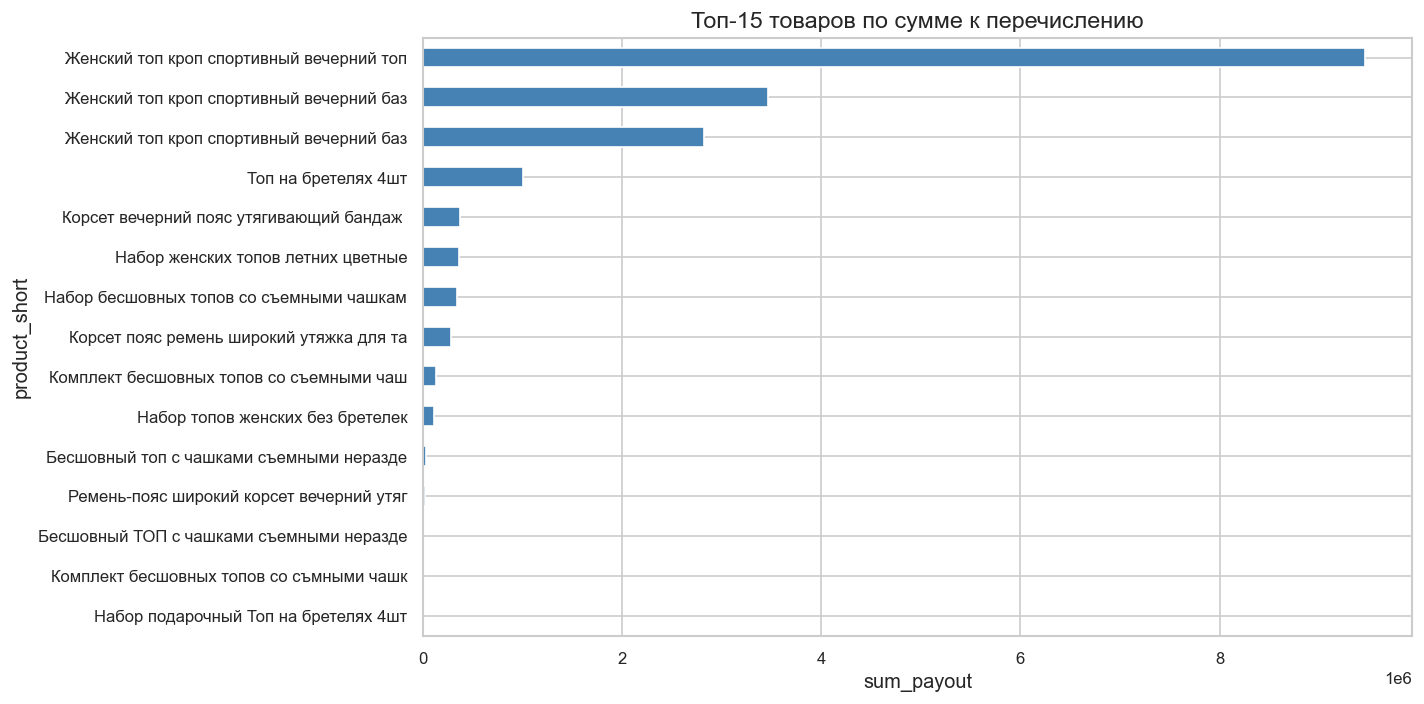

In [16]:
if "product_name" in df.columns:
    by_prod = df.groupby("product_name").agg(
        payout=("payout", "sum") if "payout" in df.columns else (df.columns[0], "count"),
        qty=("quantity", "sum") if "quantity" in df.columns else (df.columns[0], "count"),
    ).reset_index()
    by_prod = by_prod.rename(columns={"payout": "sum_payout"}) if "payout" in df.columns else by_prod
    col = "sum_payout" if "sum_payout" in by_prod.columns else "payout"
    top_payout = by_prod.nlargest(15, col)
    if len(top_payout) > 0:
        top_payout = top_payout.copy()
        top_payout["product_short"] = top_payout["product_name"].astype(str).str[:40]
        fig, ax = plt.subplots(figsize=(12, 6))
        top_payout.sort_values(col).plot(x="product_short", y=col, kind="barh", ax=ax, color="steelblue", legend=False)
        ax.set_title("Топ-15 товаров по сумме к перечислению")
        ax.set_xlabel(col)
        plt.tight_layout()
        plt.show()
    else:
        print("Нет данных по товарам.")

**Вывод:** Топ товаров по выручке задаёт приоритеты по ассортименту и остаткам.

## Итоговые выводы

- **Объём:** по отчёту виден масштаб недели (поставки, позиции, период). Сумма «к перечислению» — чистая выручка продавца после комиссий WB.
- **География:** топ офисов доставки показывает ключевые регионы сбыта.
- **Динамика:** графики по дням отражают равномерность продаж в отчётной неделе.
- **Категории и товары:** распределение по предметам и топ товаров по выручке помогают фокусировать ассортимент и закупки.